# Day 51 — LLM Landscape 2026
### Comparing frontier models, pricing, and building a model selection framework

In [1]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 150)

 Build the model comparison dataset

In [2]:
data_dir = r'C:\DS-AI-75d\.vscode\week08'

models = [
    {'provider': 'OpenAI', 'model': 'GPT-5.5', 'tier': 'flagship', 'input_cost': 2.50, 'output_cost': 15.00, 'context_k': 256, 'best_for': 'general reasoning, coding, broad tool use'},
    {'provider': 'OpenAI', 'model': 'GPT-5.5 mini', 'tier': 'budget', 'input_cost': 0.25, 'output_cost': 1.00, 'context_k': 256, 'best_for': 'high-volume chat, simple tasks'},
    {'provider': 'Anthropic', 'model': 'Claude Opus 4.7', 'tier': 'flagship', 'input_cost': 10.00, 'output_cost': 50.00, 'context_k': 500, 'best_for': 'complex reasoning, long-context analysis'},
    {'provider': 'Anthropic', 'model': 'Claude Sonnet 4.6', 'tier': 'balanced', 'input_cost': 3.00, 'output_cost': 15.00, 'context_k': 500, 'best_for': 'production apps, coding agents, writing'},
    {'provider': 'Anthropic', 'model': 'Claude Haiku 4.5', 'tier': 'budget', 'input_cost': 0.80, 'output_cost': 4.00, 'context_k': 200, 'best_for': 'fast responses, simple classification'},
    {'provider': 'Google', 'model': 'Gemini 3 Pro', 'tier': 'flagship', 'input_cost': 3.50, 'output_cost': 14.00, 'context_k': 1000, 'best_for': 'huge context, multimodal tasks'},
    {'provider': 'Google', 'model': 'Gemini 2.5 Flash', 'tier': 'budget', 'input_cost': 0.15, 'output_cost': 0.60, 'context_k': 1000, 'best_for': 'high-volume RAG, summarisation'},
    {'provider': 'Meta', 'model': 'Llama 4 Maverick', 'tier': 'open-weight', 'input_cost': 0.0, 'output_cost': 0.0, 'context_k': 1000, 'best_for': 'self-hosted, zero per-token cost at scale'},
    {'provider': 'DeepSeek', 'model': 'DeepSeek V3', 'tier': 'open-weight', 'input_cost': 0.27, 'output_cost': 1.10, 'context_k': 128, 'best_for': 'cheap strong reasoning, coding'},
]

df = pd.DataFrame(models)
df

,provider,model,tier,input_cost,output_cost,context_k,best_for
0,OpenAI,GPT-5.5,flagship,2.50,15.0,256,"general reasoning, coding, broad tool use"
1,OpenAI,GPT-5.5 mini,budget,0.25,1.0,256,"high-volume chat, simple tasks"
2,Anthropic,Claude Opus 4.7,flagship,10.00,50.0,500,"complex reasoning, long-context analysis"
3,Anthropic,Claude Sonnet 4.6,balanced,3.00,15.0,500,"production apps, coding agents, writing"
4,Anthropic,Claude Haiku 4.5,budget,0.80,4.0,200,"fast responses, simple classification"
5,Google,Gemini 3 Pro,flagship,3.50,14.0,1000,"huge context, multimodal tasks"
6,Google,Gemini 2.5 Flash,budget,0.15,0.6,1000,"high-volume RAG, summarisation"
7,Meta,Llama 4 Maverick,open-weight,0.00,0.0,1000,"self-hosted, zero per-token cost at scale"
8,DeepSeek,DeepSeek V3,open-weight,0.27,1.1,128,"cheap strong reasoning, coding"


 Cost analysis: what does a real workload actually cost?

In [3]:
def estimate_cost(row, input_tokens, output_tokens):
    cost = (input_tokens / 1_000_000) * row['input_cost'] + (output_tokens / 1_000_000) * row['output_cost']
    return round(cost, 4)

# simulate a RAG chatbot: 5000 input tokens (context), 300 output tokens, answered 10000 times
df['cost_per_10k_requests'] = df.apply(lambda r: estimate_cost(r, 5000, 300) * 10000, axis=1)
df[['provider', 'model', 'tier', 'cost_per_10k_requests']].sort_values('cost_per_10k_requests')

,provider,model,tier,cost_per_10k_requests
7,Meta,Llama 4 Maverick,open-weight,0.0
6,Google,Gemini 2.5 Flash,budget,9.0
1,OpenAI,GPT-5.5 mini,budget,15.0
8,DeepSeek,DeepSeek V3,open-weight,17.0
4,Anthropic,Claude Haiku 4.5,budget,52.0
0,OpenAI,GPT-5.5,flagship,170.0
3,Anthropic,Claude Sonnet 4.6,balanced,195.0
5,Google,Gemini 3 Pro,flagship,217.0
2,Anthropic,Claude Opus 4.7,flagship,650.0


## Note on "free" open-weight models
Llama 4 shows $0/request because there's no per-token API charge — but it
still costs money to run. You're paying for GPU hosting instead of tokens.
Self-hosting only beats API pricing above a certain volume threshold,
roughly $3k-10k/month in equivalent API spend, depending on the model size
and GPU pricing at the time.

Visualize the cost spread

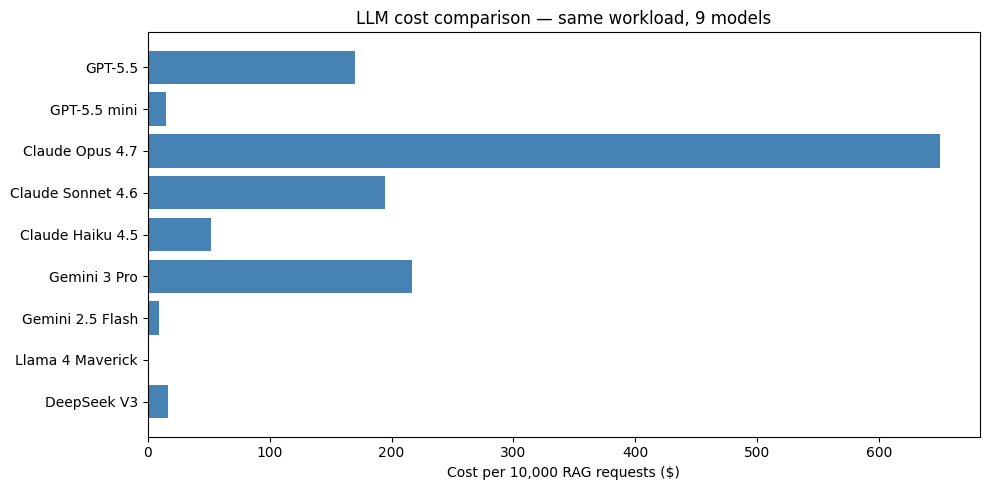

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.barh(df['model'], df['cost_per_10k_requests'], color='steelblue')
plt.xlabel('Cost per 10,000 RAG requests ($)')
plt.title('LLM cost comparison — same workload, 9 models')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The decision framework

In [5]:
def recommend_model(task_type, budget='balanced', context_needed_k=50):
    candidates = df[df['context_k'] >= context_needed_k].copy()

    if budget == 'lowest':
        candidates = candidates.sort_values('cost_per_10k_requests')
    elif budget == 'flagship':
        candidates = candidates[candidates['tier'] == 'flagship'].sort_values('input_cost')
    else:
        candidates = candidates[candidates['tier'].isin(['balanced', 'budget'])].sort_values('cost_per_10k_requests')

    if task_type == 'coding':
        candidates = candidates[candidates['provider'].isin(['Anthropic', 'OpenAI', 'DeepSeek'])]
    elif task_type == 'long_document':
        candidates = candidates.sort_values('context_k', ascending=False)
    elif task_type == 'high_volume':
        candidates = candidates.sort_values('cost_per_10k_requests')

    return candidates.head(3)[['provider', 'model', 'tier', 'input_cost', 'output_cost', 'context_k', 'best_for']]

In [6]:
recommend_model(task_type='coding', budget='balanced')

,provider,model,tier,input_cost,output_cost,context_k,best_for
1,OpenAI,GPT-5.5 mini,budget,0.25,1.0,256,"high-volume chat, simple tasks"
4,Anthropic,Claude Haiku 4.5,budget,0.80,4.0,200,"fast responses, simple classification"
3,Anthropic,Claude Sonnet 4.6,balanced,3.00,15.0,500,"production apps, coding agents, writing"


 Test two more realistic scenarios

In [7]:
print("Long document analysis, flagship quality:")
display(recommend_model(task_type='long_document', budget='flagship', context_needed_k=200))

print("\nHigh-volume production chatbot, lowest cost:")
display(recommend_model(task_type='high_volume', budget='lowest'))

Long document analysis, flagship quality:


,provider,model,tier,input_cost,output_cost,context_k,best_for
5,Google,Gemini 3 Pro,flagship,3.5,14.0,1000,"huge context, multimodal tasks"
2,Anthropic,Claude Opus 4.7,flagship,10.0,50.0,500,"complex reasoning, long-context analysis"
0,OpenAI,GPT-5.5,flagship,2.5,15.0,256,"general reasoning, coding, broad tool use"



High-volume production chatbot, lowest cost:


,provider,model,tier,input_cost,output_cost,context_k,best_for
7,Meta,Llama 4 Maverick,open-weight,0.00,0.0,1000,"self-hosted, zero per-token cost at scale"
6,Google,Gemini 2.5 Flash,budget,0.15,0.6,1000,"high-volume RAG, summarisation"
1,OpenAI,GPT-5.5 mini,budget,0.25,1.0,256,"high-volume chat, simple tasks"


## LLM Selection Decision Framework — Summary

**1. Default to budget/balanced tier unless the task demands flagship reasoning.**
Sonnet-class and mini-class models handle ~80% of production tasks (chat,
RAG, classification, summarisation) at a fraction of flagship cost. Reserve
flagship models (Opus, GPT-5.5, Gemini 3 Pro) for tasks where errors are
expensive — legal review, complex multi-step agents, critical code review.

**2. Context window needs should filter first, cost second.**
A cheap model that can't fit your document is not actually cheap — you'd
need to chunk and re-query, adding cost and complexity back in. Check
context_k before cost.

**3. Self-hosted open-weight models (Llama, DeepSeek) win at high volume.**
Below ~$3k/month equivalent API spend, hosted APIs are simpler and cheaper
once you account for engineering time. Above that, self-hosting starts
paying for itself.

**4. Coding and agentic tasks favour Anthropic and OpenAI specifically.**
Both have the strongest tool-use and multi-step reasoning track record as
of 2026 — this matters more than raw benchmark score for agent-style work.

**5. Always validate with a small real-traffic test before committing.**
Benchmarks and pricing tables (like the one above) are a starting filter,
not a final answer — task-specific performance varies more than leaderboards
suggest.